In [1]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [ ]:

# outfig_dir = Path('talk_figs/mcdermott_update/figs')
# outfig_dir.mkdir(parents=True, exist_ok=True)


In [ ]:
def get_category_accuracies(predictions,labels,target):
    """
    Returns the accuracy for target category.
    """
    correct = 0
    total = 0
    for idx in range(len(labels)):
        label = labels[idx]
        if label==target:
            prediction = predictions[idx]
            if label==prediction:
                correct = correct+1
            total = total+1
    return correct/total


def format_model_str(path):
    path_str = str(path)
    
    # 1. Architecture
    arch_match = re.search(r'(kell2018|resnet\d+|byol-a)', path_str)
    arch = arch_match.group(1) if arch_match else 'unknown'

    # 2. Determine SSL or supervised
    ssl_keywords = ['barlow', 'mmcr', 'invariant', 'equivariant']
    is_ssl = any(k in path_str for k in ssl_keywords)
    
    # 3. Determine if dual
    is_dual = 'dual' in path_str or 'dualtask' in path_str

    # 4. Task modifiers
    modifiers = []
    if 'word_speaker_audioset' in path_str:
        modifiers.append('multi-task')
    elif 'word' in path_str:
        modifiers.append('word')
    elif 'jsin' in path_str:
        modifiers.append('jsin audioset')
    elif 'audioset' in path_str:
        modifiers.append('audioset')

    # 5. Equivariant lambda
    eq_lambda = ''
    if 'equivariant' in path_str or 'eq_lmbda' in path_str:
        lambda_match = re.search(r'eq_lmbda_([-\d.e]+)', path_str)
        if lambda_match:
            eq_lambda = str(float(lambda_match.group(1)))  # convert to numeric string

    # 6. Compose task string
    task_parts = []
    if is_ssl:
        if is_dual:
            task_parts.append('ssl dual')
        elif eq_lambda:
            task_parts.append('ssl eq')
        else:
            task_parts.append('ssl')
        
        # Add base modifier if not multi-task
        if 'multi-task' not in modifiers:
            task_parts.extend(modifiers)  # e.g., word, audioset
    else:
        task_parts.append('supervised')
        task_parts.extend(modifiers)

    # Append eq_lambda if applicable
    if eq_lambda:
        task_parts.append(f'λ={eq_lambda}')

    task = ' '.join(task_parts)

    # 7. Data augmentations
    aug_str = ''
    if 'paired_augmentations' in path_str or ('resnet18' in arch and 'w_invar_aug' not in path_str):
        aug_str = 'paired augmentations'
    elif 'no_shared_fg_augments' in path_str:
        aug_str = 'unpaired augs'
    
    # 8. Test layer (last part of filename stem)
    test_layer = Path(path).stem.split("_")[-1]

    # 9. Full model name
    model_name = f"{arch} {task}"
    if aug_str:
        model_name = f"{model_name} {aug_str}"

    return model_name, arch, test_layer, eq_lambda




## Get ESC 50 results for each model

In [4]:
path_to_esc_results = Path("esc_analysis")

all_model_results = list(path_to_esc_results.rglob("*barlow*kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("audioset_*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("resnet18_barlow*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("resnet50_barlow*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("kell2018_barlow*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("word_kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("config_linear*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("byola*/saved_vars*.pickle"))
# all_model_results

test_layers = [
                'preproc',
                'batchnorm0',
                'conv0',
                'relu0',
                'maxpool0',
                'batchnorm1',
                'conv1',
                'relu1',
                'maxpool1',
                'batchnorm2',
                'conv2',
                'relu2',
                'conv3',
                'relu3',
                'conv4',
                'relu4',
                'avgpool',
                'fullyconnected',
                'relufc',
                'dropout',
                ]
                
resnet18_layer_order = [
                'preproc',
                'conv1',
                'bn1',
                'relu1',
                'maxpool1',
                'layer1',
                'layer2',
                'layer3',
                'layer4',
                'avgpool',
            ]            
layer_order_dict = {l:i for i,l in enumerate(test_layers)}
df_list = []

for i, results_path in enumerate(all_model_results):
    path_str = str(results_path)

    if 'kell2018' in path_str and not results_path.parent.stem.startswith('kell2018'):
        if 'eq_lmbda' in path_str:
            # if 'fixed_loss' not in path_str:
            continue 
                
    if 'projects' in str(results_path):
        continue 
    results = pd.read_pickle(results_path)
    overall_acc = results['overall_acc']

    model_name, arch_class, test_layer, eq_lmbda = format_model_str(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda, overall_acc=overall_acc)
    if i == 0:
        category_list = np.array(list(results['target_to_category'].values()))
    # print(test_layer)
    
    # category_accuracies = np.stack(results['category_accuracies'], axis=0)
    # ## get category mean across splits 
    # means = category_accuracies.mean(0)
    # # get error (is standard deviation like in original script)
    # SEMs = category_accuracies.std(0)
    # # overall_acc 
    # overall_acc = results['overall_acc']

    df_list.append(data)

esc_50_df = pd.DataFrame.from_records(df_list)
esc_50_df['test_layer'] = esc_50_df['test_layer'].astype('str')

esc_50_df = esc_50_df.loc[esc_50_df['test_layer'].map({k: i for i, k in enumerate(test_layers)}) \
                .sort_values().index]

In [5]:
esc_50_df.test_layer.unique()

array(['preproc', 'batchnorm0', 'conv0', 'relu0', 'maxpool0',
       'batchnorm1', 'conv1', 'relu1', 'maxpool1', 'batchnorm2', 'conv2',
       'relu2', 'conv3', 'relu3', 'conv4', 'relu4', 'avgpool',
       'fullyconnected', 'relufc', 'dropout', 'layer1', 'layer2', 'bn1',
       'layer3', 'layer4', 'final'], dtype=object)

In [6]:
esc_50_df.model_name.unique()

array(['kell2018 ssl dual λ=0.0', 'kell2018 ssl eq λ=0.1',
       'resnet18 ssl eq λ=0.4 paired augmentations',
       'kell2018 supervised multi-task', 'resnet18 ssl eq λ=0.01',
       'resnet18 ssl eq λ=0.1 paired augmentations', 'resnet18 ssl',
       'resnet18 ssl eq λ=0.3 paired augmentations',
       'resnet18 ssl eq λ=1.0', 'kell2018 ssl word',
       'kell2018 ssl eq λ=0.2', 'kell2018 ssl eq λ=0.3',
       'kell2018 ssl dual λ=0.5', 'kell2018 ssl eq λ=0.8',
       'kell2018 supervised word',
       'resnet18 ssl eq λ=0.5 paired augmentations',
       'resnet18 ssl eq λ=0.1', 'resnet18 ssl eq λ=0.5',
       'resnet18 ssl eq λ=0.4', 'resnet18 ssl eq λ=0.3',
       'resnet18 ssl eq λ=0.2',
       'resnet18 ssl eq λ=0.2 paired augmentations',
       'kell2018 supervised audioset', 'kell2018 ssl eq λ=0.5',
       'kell2018 ssl eq λ=0.4', 'kell2018 ssl eq audioset λ=0.5',
       'kell2018 ssl jsin audioset', 'kell2018 ssl dual λ=0.1',
       'kell2018 ssl eq audioset λ=0.0',
       '

## Get word task results 

In [7]:
def format_model_str_word_task(path):
    full_path_str = str(path.stem)
    path_str = full_path_str.split('_linear_eval')[0]

    # 1. Architecture
    arch_match = re.search(r'(kell2018|resnet\d+|byol-a)', path_str)
    arch = arch_match.group(1) if arch_match else 'unknown'

    # 2. Determine SSL or supervised
    ssl_keywords = ['barlow', 'mmcr', 'invariant', 'equivariant']
    is_ssl = any(k in path_str for k in ssl_keywords)
    
    # 3. Determine if dual
    is_dual = 'dual' in path_str or 'dualtask' in path_str

    # 4. Task modifiers
    modifiers = []
    if 'word_speaker_audioset' in path_str:
        modifiers.append('multi-task')
    elif 'word' in path_str:
        modifiers.append('word')
    elif 'jsin' in path_str:
        modifiers.append('jsin audioset')
    elif 'audioset' in path_str:
        modifiers.append('audioset')

    # 5. Equivariant lambda
    eq_lambda = ''
    if 'equivariant' in path_str or 'eq_lmbda' in path_str:
        lambda_match = re.search(r'eq_lmbda_([-\d.e]+)', path_str)
        if lambda_match:
            eq_lambda = str(float(lambda_match.group(1)))  # convert to numeric string

    # 6. Compose task string
    task_parts = []
    if is_ssl:
        if is_dual:
            task_parts.append('ssl dual')
        elif eq_lambda:
            task_parts.append('ssl eq')
        else:
            task_parts.append('ssl')
        
        # Special case: if audioset_only is present, add audioset even when eq_lambda exists
        if 'audioset_only' in full_path_str:
            task_parts.append('audioset')
        # Add base modifier if not multi-task and not eq_lambda
        elif 'multi-task' not in modifiers and not eq_lambda:
            task_parts.extend(modifiers)  # e.g., word, audioset
    else:
        task_parts.append('supervised')
        task_parts.extend(modifiers)

    # Append eq_lambda if applicable
    if eq_lambda:
        task_parts.append(f'λ={eq_lambda}')

    task = ' '.join(task_parts)

    # 7. Data augmentations
    aug_str = ''
    if 'paired_augmentations' in path_str or ('resnet18' in arch and 'w_invar_aug' not in path_str):
        aug_str = 'paired augmentations'
    elif 'no_shared_fg_augments' in path_str:
        aug_str = 'unpaired augs'
    
    # 8. Test layer (word task specific: extract from 'task_' pattern in full path)
    test_layer = full_path_str.split('task_')[-1].split('_')[0]

    # 9. Full model name
    model_name = f"{arch} {task}"
    if aug_str:
        model_name = f"{model_name} {aug_str}"

    return model_name, arch, test_layer, eq_lambda

In [8]:
path_to_word_results = Path("eval_jsin_results")
kell2018_word_results = list(path_to_word_results.rglob("*kell2018*.pkl"))
kell2018_word_results = [path for path in kell2018_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

# kell2018_word_results = list(path_to_word_results.rglob("*kell2018*.pkl"))
# kell2018_word_results = [path for path in kell2018_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

resnet18_word_results = list(path_to_word_results.rglob("resnet18*.pkl"))
resnet18_word_results = [path for path in resnet18_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

byola_results =  list(path_to_word_results.rglob("config_linear*.pkl"))
byola_results = [path for path in byola_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands', '0.01']])]

byola_results_new =  list(path_to_word_results.rglob("byola*.pkl"))
byola_results += [path for path in byola_results_new if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands', '0.01']])]

all_word_task_results = kell2018_word_results + resnet18_word_results + byola_results

df_list = []

for i, results_path in enumerate(all_word_task_results):
    path_str = str(results_path)
    # if results_path.name.startswith('audioset'):
    #     print(path_str)

    if 'kell2018' in path_str and not results_path.name.startswith('kell2018'):
        if 'eq_lmbda' in path_str:

            # if 'fixed_loss' not in path_str:
            continue 
    if 'kell2018' in path_str and not 'w_dropout_center_eval_words' in path_str:

        continue
        
    if not any([layer in str(results_path) for layer in test_layers + resnet18_layer_order]):

        continue 

    results = pd.read_pickle(results_path)
    # break 

    model_name, arch_class, test_layer, eq_lmbda = format_model_str_word_task(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda)
    data = {**data, **results}

    # print(test_layer)

    # category_accuracies = np.stack(results['category_accuracies'], axis=0)
    # ## get category mean across splits 
    # means = category_accuracies.mean(0)
    # # get error (is standard deviation like in original script)
    # SEMs = category_accuracies.std(0)
    # # overall_acc 
    # overall_acc = results['overall_acc']

    df_list.append(data)

word_df = pd.DataFrame.from_records(df_list)
word_df['test_layer'] = word_df['test_layer'].astype('str')
word_df['task'] = '800-word classification'

In [9]:
word_df.model_name.unique()

array(['kell2018 ssl eq λ=0.5', 'kell2018 ssl dual λ=0.0 unpaired augs',
       'kell2018 ssl dual λ=0.01', 'kell2018 supervised word',
       'kell2018 ssl eq λ=0.3', 'kell2018 ssl eq λ=0.1',
       'kell2018 ssl eq λ=0.4', 'kell2018 ssl eq λ=0.2',
       'kell2018 supervised multi-task', 'kell2018 ssl eq audioset λ=0.0',
       'kell2018 ssl eq audioset λ=0.5', 'kell2018 supervised audioset',
       'kell2018 ssl word', 'kell2018 ssl dual λ=0.5',
       'kell2018 ssl dual λ=0.1', 'kell2018 ssl jsin audioset',
       'kell2018 ssl dual λ=0.0', 'resnet18 ssl eq λ=0.5',
       'resnet18 ssl eq λ=0.1', 'resnet18 ssl eq λ=0.3',
       'resnet18 ssl eq λ=0.3 paired augmentations', 'resnet18 ssl',
       'resnet18 ssl eq λ=0.4', 'resnet18 ssl eq λ=0.2',
       'resnet18 ssl eq λ=0.01', 'resnet18 ssl eq λ=1.0',
       'unknown supervised', 'unknown ssl'], dtype=object)

In [10]:
df = pd.concat([word_df, esc_50_df], axis=0, ignore_index=True)
df.head()

,model_name,arch_class,test_layer,eq_lmbda,word_top1_mean,word_top1_sem,speaker_top1_mean,speaker_top1_sem,word_top5_mean,word_top5_sem,speaker_top5_mean,speaker_top5_sem,task,overall_acc
0,kell2018 ssl eq λ=0.5,kell2018,relu0,0.5,0.184229,0.001017,0.983177,0.000388,0.827061,0.006277,0.995555,2.107547e-04,800-word classification,NaN
1,kell2018 ssl dual λ=0.0 unpaired augs,kell2018,relu4,0.0,0.756403,0.001014,0.999490,0.000049,0.989996,0.000270,1.000000,2.942227e-10,800-word classification,NaN
2,kell2018 ssl dual λ=0.01,kell2018,relu4,0.01,0.734701,0.001058,0.999429,0.000051,0.988358,0.000291,1.000000,2.942227e-10,800-word classification,NaN
3,kell2018 supervised word,kell2018,relu1,,0.726751,0.001035,0.998746,0.000078,0.972820,0.000693,0.999921,1.837652e-05,800-word classification,NaN
4,kell2018 ssl eq λ=0.3,kell2018,relu2,0.3,0.811457,0.000937,0.999703,0.000035,0.993793,0.000189,0.999996,4.343880e-06,800-word classification,NaN


# Plot ESC 50 results

In [11]:
esc_50_to_plot = df[(df.arch_class == 'kell2018') & (~df.overall_acc.isna()) & (df.test_layer.str.contains('relu'))]
# esc_50_to_plot[esc_50_to_plot.eq_lmbda == ' 5e-01'].groupby(['test_layer', 'model_name']).overall_acc.max()

/tmp/ipykernel_889190/550938861.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=hue_order, rotation=90, ) #ha='right', rotation_mode='anchor')


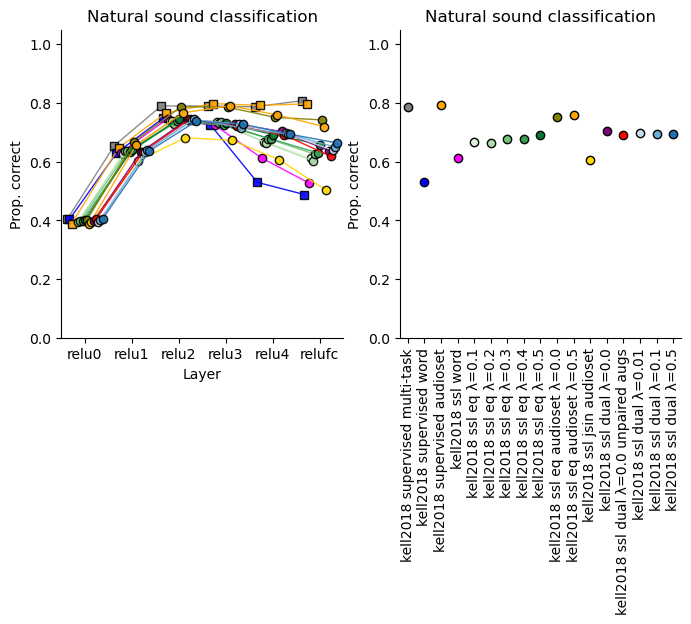

In [ ]:
hue_order = [
    # Supervised
    'kell2018 supervised multi-task',
    'kell2018 supervised word',
    'kell2018 supervised audioset',

    # SSL / Invariant
    'kell2018 ssl word',

    # SSL / Equivariant
    'kell2018 ssl eq λ=0.1',
    'kell2018 ssl eq λ=0.2',
    'kell2018 ssl eq λ=0.3',
    'kell2018 ssl eq λ=0.4',
    'kell2018 ssl eq λ=0.5',
    'kell2018 ssl eq audioset λ=0.0',  
    'kell2018 ssl eq audioset λ=0.5',  
    'kell2018 ssl jsin audioset',

    # SSL / Dual
    'kell2018 ssl dual λ=0.0',
    'kell2018 ssl dual λ=0.0 unpaired augs',
    'kell2018 ssl dual λ=0.01',
    'kell2018 ssl dual λ=0.1',
    'kell2018 ssl dual λ=0.5',
]

marker_palette = ['s' if 'supervised' in model else 'o' for model in hue_order]
             
              

# set palette 
hue_dict = {}
hue_dict['kell2018 supervised word'] = 'blue'
hue_dict['kell2018 supervised audioset'] = 'orange' 
hue_dict['kell2018 ssl eq audioset λ=0.0'] = 'olive' 
hue_dict['kell2018 ssl eq audioset λ=0.5'] = 'orange' 
hue_dict['kell2018 ssl jsin audioset'] = 'gold' 
hue_dict['kell2018 supervised multi-task'] = 'grey'
hue_dict['kell2018 ssl word'] = 'magenta'
hue_dict['kell2018 ssl dual λ=0.0'] = 'purple'
hue_dict['kell2018 ssl dual λ=0.0 unpaired augs'] = 'red'
# hue_dict['kell2018 dual equivariant 5e-01'] = 'olive'

layer_order = [
            'relu0', 'relu1', 'relu2', 'relu3', 'relu4', 'relufc'
]

eq_model_list = hue_order[4:9]
equi_palette = sns.color_palette("Greens", n_colors=len(eq_model_list)) 
equi_color_dict = dict(zip(eq_model_list, equi_palette))

dual_equi_model_list = hue_order[-3:]
dual_equi_palette = sns.color_palette("Blues", n_colors=len(dual_equi_model_list)) 
dual_equi_color_dict = dict(zip(dual_equi_model_list, dual_equi_palette))

hue_dict = {**hue_dict, **equi_color_dict, **dual_equi_color_dict}

esc_50_to_plot = df[(df.arch_class == 'kell2018') & (~df.overall_acc.isna()) & (df.test_layer.str.contains('relu'))]

fig, axes = plt.subplots(1,2,figsize=(8,4))

g = sns.pointplot(data=esc_50_to_plot, 
                order=layer_order,
                hue='model_name', y='overall_acc', #col='arch_class',
                x="test_layer",
                palette=hue_dict,
                hue_order=hue_order,
                alpha=0.9,
                dodge=0.75,
                ax = axes[0],
                legend=False,
                markers=marker_palette,
            # ls='',
                mec='k',
                mew=1,
                lw=1, ms=6
                #  height=4, 
                 )
g.set(ylim=(0, 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='Layer')

test_layers = ['relu4', 'final', 'avgpool']

to_plot = esc_50_to_plot[(esc_50_to_plot.model_name.isin(hue_order)) & esc_50_to_plot.test_layer.isin(test_layers)]
to_plot = to_plot[~((to_plot.model_name.str.contains('kell')) & to_plot.test_layer.str.contains('avgpool'))]
# models_for_esc = ['kell2018 supervised word', 'kell2018 supervised multi-task', 'byol-a ']
# esc_50_to_plot = esc_50_to_plot[esc_50_to_plot.model_name.str.contains('kell2018|byola')]
g = sns.pointplot(data=to_plot,
                order=hue_order,
                x='model_name',
                y='overall_acc',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,
                # markers=marker_palette,
                # hue_order=hue_order,
                # height=4,
                ax = axes[1],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=hue_order, rotation=90, ) #ha='right', rotation_mode='anchor')
g.set(ylim=(0., 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='')
sns.despine()


/tmp/ipykernel_889190/1672552622.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=hue_order, rotation=90, ) #ha='right', rotation_mode='anchor')


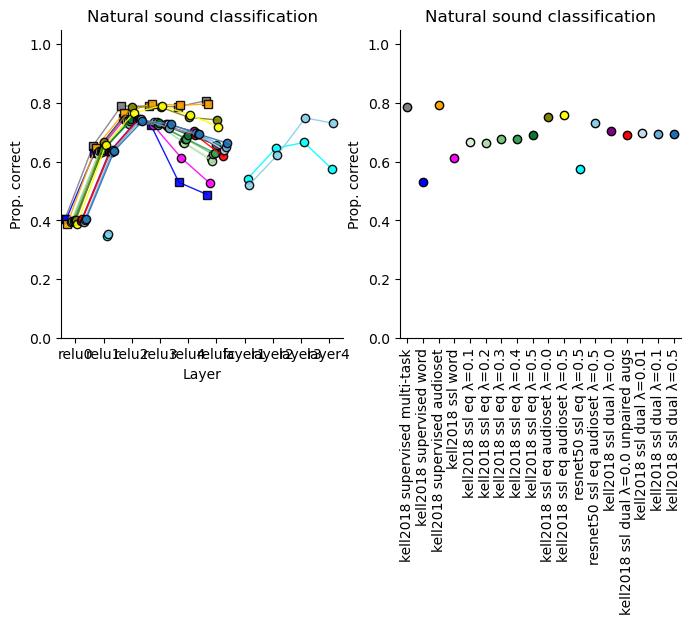

In [17]:
hue_order = [
    # Supervised
    'kell2018 supervised multi-task',
    'kell2018 supervised word',
    'kell2018 supervised audioset',

    # SSL / Invariant
    'kell2018 ssl word',

    # SSL / Equivariant
    'kell2018 ssl eq λ=0.1',
    'kell2018 ssl eq λ=0.2',
    'kell2018 ssl eq λ=0.3',
    'kell2018 ssl eq λ=0.4',
    'kell2018 ssl eq λ=0.5',
    'kell2018 ssl eq audioset λ=0.0',  
    'kell2018 ssl eq audioset λ=0.5',  

    # Resnets 50 
    'resnet50 ssl eq λ=0.5',
    'resnet50 ssl eq audioset λ=0.5',

    # SSL / Dual
    'kell2018 ssl dual λ=0.0',
    'kell2018 ssl dual λ=0.0 unpaired augs',
    'kell2018 ssl dual λ=0.01',
    'kell2018 ssl dual λ=0.1',
    'kell2018 ssl dual λ=0.5',

]

marker_palette = ['s' if 'supervised' in model else 'o' for model in hue_order]
             
              

# set palette 
hue_dict = {}
hue_dict['kell2018 supervised word'] = 'blue'
hue_dict['kell2018 supervised audioset'] = 'orange' 
hue_dict['kell2018 ssl eq audioset λ=0.0'] = 'olive' 
hue_dict['kell2018 ssl eq audioset λ=0.5'] = 'yellow' 
hue_dict['kell2018 supervised multi-task'] = 'grey'
hue_dict['kell2018 ssl word'] = 'magenta'
hue_dict['kell2018 ssl dual λ=0.0'] = 'purple'
hue_dict['kell2018 ssl dual λ=0.0 unpaired augs'] = 'red'

hue_dict['resnet50 ssl eq λ=0.5'] = 'cyan'
hue_dict['resnet50 ssl eq audioset λ=0.5'] = 'skyblue'
# hue_dict['kell2018 dual equivariant 5e-01'] = 'olive'

eq_model_list = hue_order[4:9]
equi_palette = sns.color_palette("Greens", n_colors=len(eq_model_list)) 
equi_color_dict = dict(zip(eq_model_list, equi_palette))

dual_equi_model_list = hue_order[-3:]
dual_equi_palette = sns.color_palette("Blues", n_colors=len(dual_equi_model_list)) 
dual_equi_color_dict = dict(zip(dual_equi_model_list, dual_equi_palette))

hue_dict = {**hue_dict, **equi_color_dict, **dual_equi_color_dict}

# esc_50_to_plot = df[(df.arch_class == 'kell2018') & (~df.overall_acc.isna()) & (df.test_layer.str.contains('relu'))]
esc_50_to_plot = df[  (~df.overall_acc.isna()) & (df.test_layer.str.contains('relu|layer'))]

fig, axes = plt.subplots(1,2,figsize=(8,4))

g = sns.pointplot(data=esc_50_to_plot, 
                # order=layer_order,
                hue='model_name', y='overall_acc', #col='arch_class',
                x="test_layer",
                palette=hue_dict,
                hue_order=hue_order,
                alpha=0.9,
                dodge=0.75,
                ax = axes[0],
                legend=False,
                markers=marker_palette,
            # ls='',
                mec='k',
                mew=1,
                lw=1, ms=6
                #  height=4, 
                 )
g.set(ylim=(0, 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='Layer')

test_layers = ['relu4', "layer4", 'final', 'avgpool']

to_plot = esc_50_to_plot[(esc_50_to_plot.model_name.isin(hue_order)) & esc_50_to_plot.test_layer.isin(test_layers)]
# to_plot = to_plot[~((to_plot.model_name.str.contains('kell')) & to_plot.test_layer.str.contains('avgpool'))]
# models_for_esc = ['kell2018 supervised word', 'kell2018 supervised multi-task', 'byol-a ']
# esc_50_to_plot = esc_50_to_plot[esc_50_to_plot.model_name.str.contains('kell2018|byola')]
g = sns.pointplot(data=to_plot,
                order=hue_order,
                x='model_name',
                y='overall_acc',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,
                # markers=marker_palette,
                # hue_order=hue_order,
                # height=4,
                ax = axes[1],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=hue_order, rotation=90, ) #ha='right', rotation_mode='anchor')
g.set(ylim=(0., 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='')
sns.despine()


/tmp/ipykernel_889190/1187521801.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(labels=model_names_for_x, rotation=90)
/tmp/ipykernel_889190/1187521801.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(labels=model_names_for_x, rotation=90)


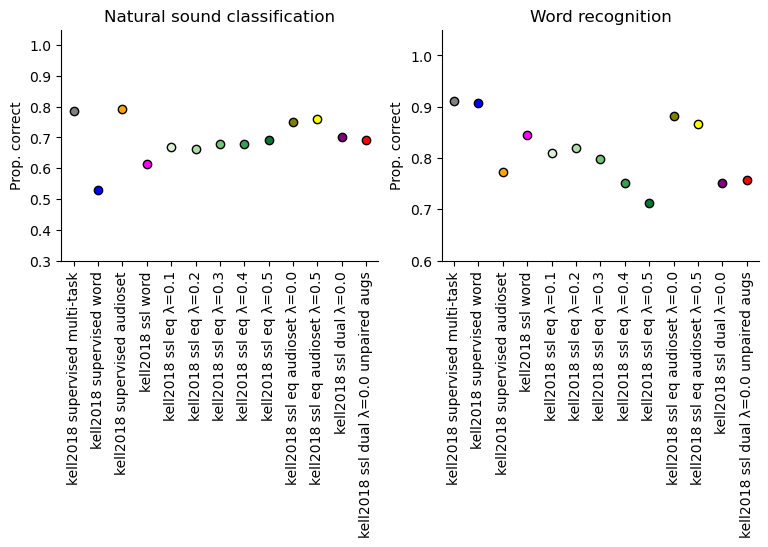

In [18]:
# ============================================================================
# Configuration
# ============================================================================

# Model selection
hue_order = [

    # Supervised
    'kell2018 supervised multi-task',
    'kell2018 supervised word',
    'kell2018 supervised audioset',

    # SSL / Invariant
    'kell2018 ssl word',

    # SSL / Equivariant
    'kell2018 ssl eq λ=0.1',
    'kell2018 ssl eq λ=0.2',
    'kell2018 ssl eq λ=0.3',
    'kell2018 ssl eq λ=0.4',
    'kell2018 ssl eq λ=0.5',
    'kell2018 ssl eq audioset λ=0.0',  
    'kell2018 ssl eq audioset λ=0.5',  

    'kell2018 ssl dual λ=0.0',
    'kell2018 ssl dual λ=0.0 unpaired augs',
]

# Layer selection
test_layers = ['relu4', 'final', 'features']


# ============================================================================
# Data Preparation
# ============================================================================

# Filter dataframe
to_plot = df[df.model_name.str.contains('kell2018|byol')].copy()
to_plot = to_plot[(to_plot.model_name.isin(hue_order)) & 
                  (to_plot.test_layer.isin(test_layers))]

word_to_plot = to_plot # .drop_duplicates('model_name')

# Format x-axis labels
model_names_for_x = hue_order

# ============================================================================
# Plotting
# ============================================================================

fig, axs = plt.subplots(1, 2,
                         figsize=(9, 3),
                        #  gridspec_kw={'wspace': 0.5}
                    )

# Plot 1: Natural sound classification
sns.pointplot(
    data=to_plot,
    x='model_name',
    y='overall_acc',
    order=hue_order,
    hue='model_name',
    palette=hue_dict,
    ax=axs[0],
    mec='k',
    mew=1,
    lw=1,
    ms=6,
    legend=False
)

axs[0].set_xticklabels(labels=model_names_for_x, rotation=90)
axs[0].set(
    ylim=(0.3, 1.05),
    title="Natural sound classification",
    ylabel='Prop. correct',
    xlabel=''
)

# Plot 2: Word recognition
sns.pointplot(
    data=word_to_plot,
    x='model_name',
    y='word_top1_mean',
    order=hue_order,
    hue='model_name',
    palette=hue_dict,
    ax=axs[1],
    mec='k',
    mew=1,
    lw=1,
    ms=6,
    legend=False
)

axs[1].set_xticklabels(labels=model_names_for_x, rotation=90)
axs[1].set(
    ylim=(0.6, 1.05),
    title="Word recognition",
    ylabel='Prop. correct',
    xlabel=''
)

# Final adjustments
sns.despine()


# plt.savefig(outfig_dir/'sup_v_invariant_models.png', 
#             transparent=True, dpi=500, bbox_inches='tight')

In [45]:
to_plot = df[df.model_name.str.contains('kell2018|byol')].copy()
to_plot


,model_name,arch_class,test_layer,eq_lmbda,word_top1_mean,word_top1_sem,speaker_top1_mean,speaker_top1_sem,word_top5_mean,word_top5_sem,speaker_top5_mean,speaker_top5_sem,task,overall_acc
0,kell2018 ssl dual λ=0.0 unpaired augs,kell2018,kell2018,0.0,0.756403,0.001014,0.999490,0.000049,0.989996,0.000270,1.000000,2.942227e-10,800-word classification,NaN
1,kell2018 ssl dual λ=0.01,kell2018,kell2018,0.01,0.734701,0.001058,0.999429,0.000051,0.988358,0.000291,1.000000,2.942227e-10,800-word classification,NaN
2,kell2018 supervised word,kell2018,word,,0.726751,0.001035,0.998746,0.000078,0.972820,0.000693,0.999921,1.837652e-05,800-word classification,NaN
3,kell2018 ssl eq λ=0.1,kell2018,kell2018,0.1,0.612794,0.001162,0.998705,0.000078,0.959728,0.000822,0.999882,2.401590e-05,800-word classification,NaN
4,kell2018 ssl eq λ=0.1,kell2018,kell2018,0.1,0.809655,0.000949,0.998945,0.000069,0.994027,0.000184,1.000000,2.942227e-10,800-word classification,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,kell2018 ssl eq λ=0.8,kell2018,dropout,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6240
523,kell2018 supervised multi-task,kell2018,dropout,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8075
524,kell2018 ssl eq λ=0.1,kell2018,dropout,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6130
525,kell2018 supervised word,kell2018,dropout,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4875


/tmp/ipykernel_1816473/486397959.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')
/tmp/ipykernel_1816473/486397959.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')


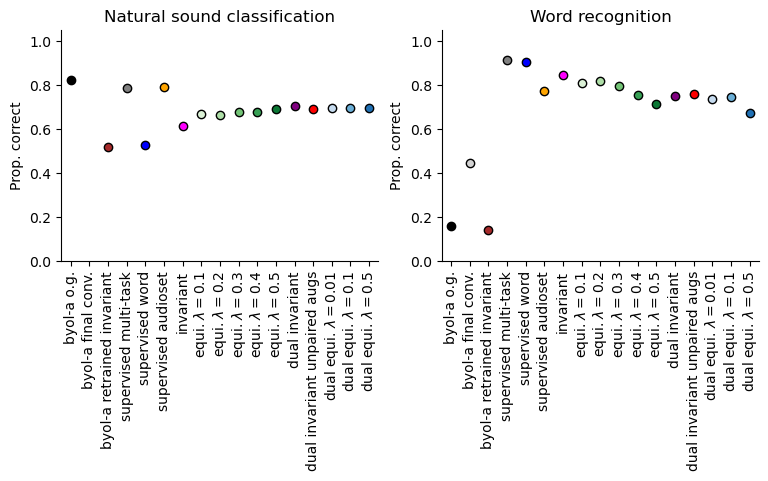

In [16]:
hue_order = [ 
              'byol-a o.g.', 
              'byol-a final conv.', 
              'byol-a retrained invariant',
              'kell2018 supervised multi-task',
              'kell2018 supervised word',
              'kell2018 supervised audioset',
              'kell2018 invariant',
              'kell2018 equivariant 1e-01',
              'kell2018 equivariant 2e-01',
              'kell2018 equivariant 3e-01',
              'kell2018 equivariant 4e-01',
              'kell2018 equivariant 5e-01',
              'kell2018 dual invariant',
              "kell2018 dual invariant unpaired augs",
              'kell2018 dual equivariant 1e-02',
              'kell2018 dual equivariant 1e-01',
              'kell2018 dual equivariant 5e-01',
            #   'kell2018 equivariant 8e-01',
              ]

marker_palette = ['s' if 'supervised' in model else 'o' for model in hue_order]
             
              

# set palette 
hue_dict = {}
hue_dict['byol-a o.g.'] = 'black'
hue_dict['byol-a final conv.'] = 'lightgrey'
hue_dict['byol-a retrained invariant'] = 'brown'
hue_dict['kell2018 supervised word'] = 'blue'
hue_dict['kell2018 supervised audioset'] = 'orange' 
hue_dict['kell2018 supervised multi-task'] = 'grey'
hue_dict['kell2018 invariant'] = 'magenta'
hue_dict['kell2018 dual invariant'] = 'purple'
hue_dict['kell2018 dual invariant unpaired augs'] = 'red'

# hue_dict['kell2018 dual equivariant 5e-01'] = 'olive'

model_names_for_x = []

for name in hue_order:
    name = name.replace('kell2018 ', '')
    if "e-0" in name:
        lmbda = name.split(' ')[-1]
        if 'dual' in name:
            name = f"dual equi. $\\lambda=${float(lmbda)}"
        else:
            name = f"equi. $\\lambda=${float(lmbda)}"

    model_names_for_x.append(name)



layer_order = [
            'relu0', 'relu1', 'relu2', 'relu3', 'relu4', 'relufc'
]

eq_model_list = hue_order[7:12]
equi_palette = sns.color_palette("Greens", n_colors=len(eq_model_list)) 
equi_color_dict = dict(zip(eq_model_list, equi_palette))

dual_equi_model_list = hue_order[-3:]
dual_equi_palette = sns.color_palette("Blues", n_colors=len(dual_equi_model_list)) 
dual_equi_color_dict = dict(zip(dual_equi_model_list, dual_equi_palette))

hue_dict = {**hue_dict, **equi_color_dict, **dual_equi_color_dict}

fig, axs = plt.subplots(1,2, figsize=(9,3))

to_plot  = df[df.model_name.str.contains('kell2018|byol')].copy()

test_layers = ['relu4', 'final', 'features']

to_plot = to_plot[(to_plot.model_name.isin(hue_order)) & to_plot.test_layer.isin(test_layers)]
# to_plot = to_plot[~((to_plot.model_name.str.contains('kell')) & to_plot.test_layer.str.contains('avgpool'))]
# models_for_esc = ['kell2018 supervised word', 'kell2018 supervised multi-task', 'byol-a ']
# esc_50_to_plot = esc_50_to_plot[esc_50_to_plot.model_name.str.contains('kell2018|byola')]
g = sns.pointplot(data=to_plot,
                order=hue_order,
                x='model_name',
                y='overall_acc',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,

                # hue_order=hue_order,
                # height=4,
                ax = axs[0],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')
g.set(ylim=(0., 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='')
sns.despine()


# word_to_plot = to_plot[(~to_plot.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)

word_to_plot = to_plot.drop_duplicates('model_name')

g = sns.pointplot(data=word_to_plot,
                order=hue_order,
                x='model_name',
                y='word_top1_mean',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,

                # hue_order=hue_order,
                # height=4,
                ax = axs[1],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')
g.set(ylim=(0, 1.05), title="Word recognition", ylabel='Prop. correct', xlabel='')
sns.despine()

# plt.subplots_adjust(wspace=0.5)

# speaker_to_plot = to_plot[(~to_plot.speaker_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
# speaker_to_plot = speaker_to_plot.sort_values('speaker_top1_mean', ascending=False).drop_duplicates('model_name')

# g = sns.pointplot(data=to_plot,
#                 order=hue_order,
#                 hue="model_name",
#                 palette=hue_dict,
#                 y='speaker_top1_mean', 
#                 x="model_name", 
#                 ax=axs[2],
#                 # ls='',
#                 # markers=marker_palette,
#                 mec='k',
#                 mew=1,
#                 lw=1, ms=6
#                 )
# # g.set_xticklabels(labels=model_names_for_x, rotation=90)
# g.set(ylim=(0, 1.05), title="Speaker recognition", ylabel='Prop. correct', xlabel='')
# g.set_xticklabels(labels=model_names_for_x, rotation=90,)# ) #ha='right', rotation_mode='anchor')

# # handles, labels = g.get_legend_handles_labels()
# labels = [label.replace('kell2018 ', '') for label in labels]
# Create a new legend with customized labels and title
# g.legend(handles, labels, frameon=False, fontsize=8)

sns.despine()


# plt.savefig(outfig_dir/'all_models_speech_esc_relu4.png', transparent=True,dpi=500,  bbox_inches='tight')

